# Лабораторная работа #6: Предсказание товарооборота с использованием временных рядов

## Описание задачи и данных

Задача состоит в предсказании ежедневного объема заказов (товарооборота) книжного интернет-магазина для эффективного планирования ресурсов (персонала на сборку и упаковку).

Датасет `tovar_moving.csv` содержит два столбца:

* `date` — дата заказа (формат YYYY-MM-DD);
* `quantity` (qty) — количество книг, заказанных в этот день.

In [1]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np

# Для анализа временных рядов
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.api as sm

# Модели временных рядов
from statsmodels.tsa.api import SimpleExpSmoothing
from statsmodels.tsa.ar_model import AutoReg

# Для визуализации
from matplotlib import pyplot as plt

# Для метрик
from sklearn.metrics import mean_squared_error

%matplotlib inline
plt.style.use('seaborn-v0_8') # Стиль для графиков

## 1. Загрузка данных и откладывание тестового значения

In [2]:
# Считываем датасет
# Устанавливаем столбец 'date' как индекс и парсим его как даты
# Формат YYYY-MM-DD, поэтому dayfirst=False (по умолчанию)
df = pd.read_csv("tovar_moving.csv",  
                 index_col=['date'], 
                 parse_dates=['date']
                )

# Извлекаем временной ряд количества книг (qty)
ts = df['qty']

print("Первые 5 строк датасета:")
print(ts.head())

print("\nПоследние 5 строк датасета:")
print(ts.tail())

Первые 5 строк датасета:
date
2009-12-25     72314.0
2009-12-26     66586.0
2009-12-27    125199.0
2009-12-28     91544.0
2009-12-29     76995.0
Name: qty, dtype: float64

Последние 5 строк датасета:
date
2013-11-28    320717.0
2013-11-29    444416.0
2013-11-30    323577.0
2013-12-01    170665.0
2013-12-02    423846.0
Name: qty, dtype: float64


In [3]:
# Отложите в test последнее значение временного ряда.
# Остальная часть данных будет тренировочной выборкой.

test_ts = ts.iloc[-1]
train_ts = ts.iloc[:-1]

print(f"Размер исходного ряда: {len(ts)}")
print(f"Размер тренировочной выборки: {len(train_ts)}")
print(f"Размер тестовой выборки (последнее значение): {len(test_ts) if hasattr(test_ts, '__len__') else 1}")

print(f"\nПоследнее значение в тренировочной выборке (для проверки): {train_ts.iloc[-1]}")
print(f"Фактическое отложенное значение (тестовая выборка): {test_ts}")

Размер исходного ряда: 1439
Размер тренировочной выборки: 1438
Размер тестовой выборки (последнее значение): 1

Последнее значение в тренировочной выборке (для проверки): 170665.0
Фактическое отложенное значение (тестовая выборка): 423846.0


## 2. Анализ временного ряда на наличие тренда и сезонности

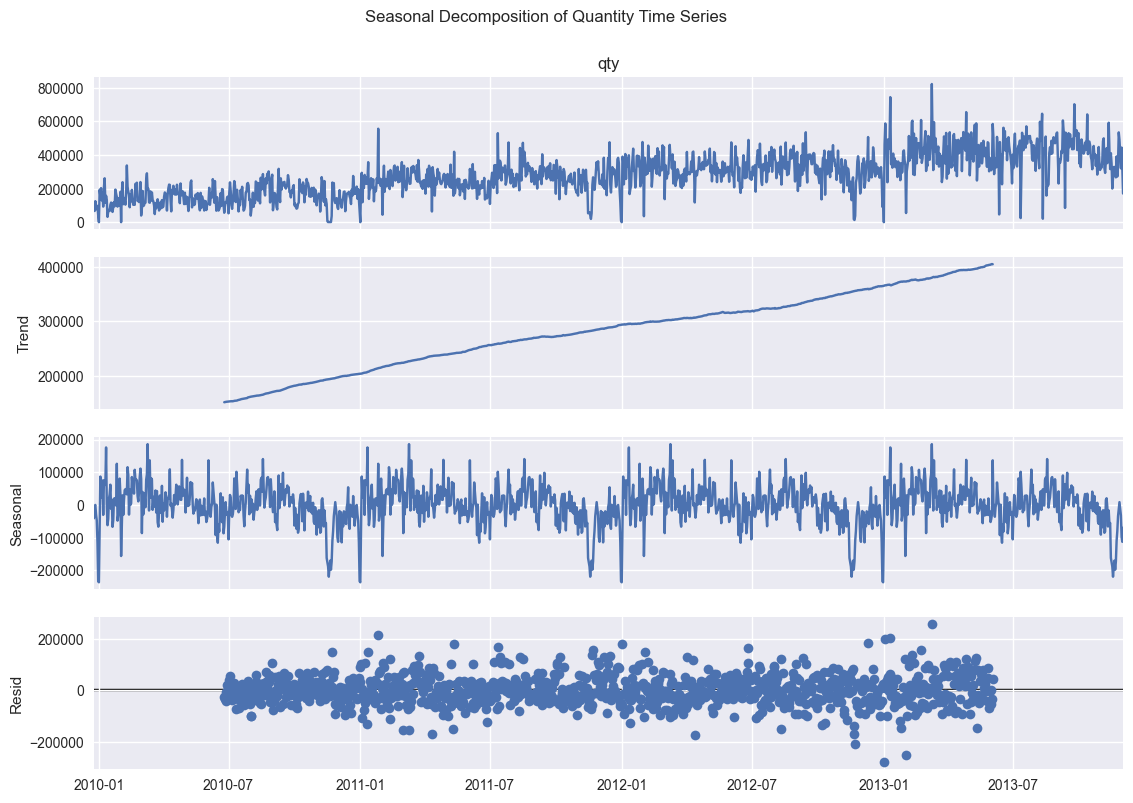

In [4]:
# Проанализируем временной ряд на наличие тренда и сезонности с помощью декомпозиции
# Используем аддитивную модель seasonal_decompose, так как размах колебаний со временем не сильно меняется визуально.
# period=365 для ежедневных данных (годовая сезонность)

# Может занять некоторое время из-за размера данных
decomposition = seasonal_decompose(train_ts, model='additive', period=365)

# Визуализируем результат декомпозиции
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Seasonal Decomposition of Quantity Time Series', y=1.02)
plt.show()

**Выводы по декомпозиции:**
- **Тренд (Trend):** Присутствует явный восходящий тренд в объеме заказов с течением времени.
- **Сезонность (Seasonal):** Наблюдается сильная годовая сезонность с пиками и спадами, повторяющимися каждый год.
- **Остаток (Residual):** После удаления тренда и сезонности остаются остаточные шумы.

## 3. Прогноз с помощью экспоненциального сглаживания

In [5]:
# Построим прогноз на одно последнее значение с помощью экспоненциального сглаживания (Simple Exp. Smoothing)

# Инициализируем модель SimpleExpSmoothing на тренировочной выборке
ses = SimpleExpSmoothing(train_ts)

# Задаем параметр сглаживания alpha
alpha = 0.7

# Обучаем модель с заданным alpha (optimized=False чтобы использовать именно наше alpha)
ses_model = ses.fit(smoothing_level=alpha, optimized=False)

# Делаем прогноз на 1 шаг вперед
ses_pred = ses_model.forecast(1)

print(f"Прогноз SES (alpha={alpha}): {ses_pred.iloc[0]:.2f}")
print(f"Фактическое значение: {test_ts:.2f}")

Прогноз SES (alpha=0.7): 225015.52
Фактическое значение: 423846.00


/Users/adamenko_ss/Desktop/personal/herzen/venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


## 4. Проверка ряда на стационарность и определение порядка интегрирования (d)

Стационарный временной ряд — это ряд, статистические свойства которого (среднее, дисперсия, автокорреляция) не меняются со временем. Многие модели временных рядов, включая AR, требуют стационарности.

Проверим тренировочный ряд на стационарность с помощью критерия Дики-Фуллера (Augmented Dickey-Fuller test).

In [6]:
# Определим функцию для проведения и вывода результатов теста Дики-Фуллера
def stat_test(ts):
    print('Результаты теста Дики-Фуллера:')
    test = sm.tsa.adfuller(ts)
    print ('adf: ', test[0] ) # Тестовая статистика
    print ('p-value: ', test[1]) # P-значение
    print('Critical values: ', test[4]) # Критические значения для разных уровней значимости

    # Сравнение p-value с уровнем значимости (обычно 0.05)
    if test[1] > 0.05:
        print ('p-value > 0.05: Ряд нестационарен')
        # Сравнение тестовой статистики с критическим значением 5%
        if test[0] > test[4]['5%']:
            print ('Тестовая статистика > Критического значения (5%): Есть единичные корни, ряд нестационарен')
        else:
             # Эта ветка маловероятна при p > 0.05, но добавим для полноты
             print ('Тестовая статистика < Критического значения (5%): Возможно, есть нюансы интерпретации, но основной вывод: ряд нестационарен по p-value')
    else:
        print ('p-value <= 0.05: Ряд стационарен (отвергаем нулевую гипотезу о наличии единичного корня)')

# Проводим тест на тренировочной выборке
stat_test(train_ts)

Результаты теста Дики-Фуллера:
adf:  -2.255302641033783
p-value:  0.1867890312341704
Critical values:  {'1%': -3.434973278556316, '5%': -2.8635818545830376, '10%': -2.567857072940785}
p-value > 0.05: Ряд нестационарен
Тестовая статистика > Критического значения (5%): Есть единичные корни, ряд нестационарен


**Интерпретация теста Дики-Фуллера:**
- Если p-value меньше или равно выбранному уровню значимости (обычно 0.05), мы отвергаем нулевую гипотезу (наличие единичного корня) и делаем вывод, что ряд стационарен.
- Если p-value больше 0.05, мы не можем отвергнуть нулевую гипотезу, и ряд считается нестационарным.

Порядок интегрирования (d) — это количество раз, которое необходимо взять разность временного ряда, чтобы он стал стационарным. Если ряд уже стационарен (p-value <= 0.05), то d=0. Если нет, нужно брать разность первого порядка (ts.diff().dropna()) и проверять стационарность снова, и так далее, пока ряд не станет стационарным.

In [7]:
# Если ряд нестационарен, проверяем его разность первого порядка
# Получаем разность первого порядка и удаляем первое значение (NaN)
train_ts_diff1 = train_ts.diff().dropna()

print("\nРезультаты теста Дики-Фуллера для разности первого порядка:")
stat_test(train_ts_diff1)


Результаты теста Дики-Фуллера для разности первого порядка:
Результаты теста Дики-Фуллера:
adf:  -13.780727380503734
p-value:  9.307227521341653e-26
Critical values:  {'1%': -3.434973278556316, '5%': -2.8635818545830376, '10%': -2.567857072940785}
p-value <= 0.05: Ряд стационарен (отвергаем нулевую гипотезу о наличии единичного корня)


**Выводы по стационарности:**
- Исходный тренировочный ряд является нестационарным (p-value > 0.05).
- Разность первого порядка ряда является стационарной (p-value <= 0.05).

Таким образом, порядок интегрирования `d = 1`.

## 5. Определение порядка модели AR (p) по графику частичной автокорреляции (PACF)

Для определения порядка AR(p) модели используется график частичной автокорреляции (PACF). Порядок `p` соответствует числу значимых лагов на графике PACF, после которого значения резко падают до незначимых (пересекают доверительный интервал).

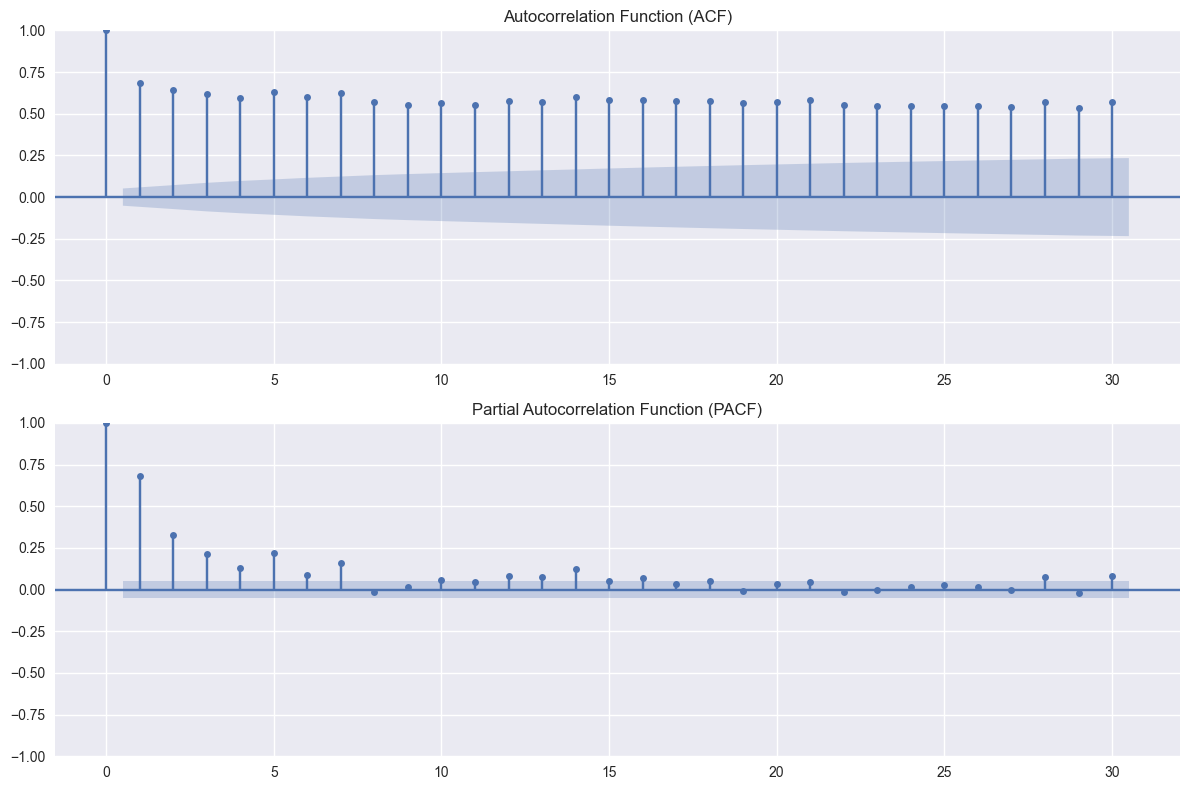

In [8]:
# Построим графики автокорреляции (ACF) и частичной автокорреляции (PACF) для тренировочного ряда

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# График ACF (Автокорреляция)
sm.graphics.tsa.plot_acf(train_ts, lags=30, ax=axes[0]) # lags можно подбирать
axes[0].set_title('Autocorrelation Function (ACF)')

# График PACF (Частичная автокорреляция)
# Важно: Для AR(p) модели порядок 'p' определяется по графику PACF
sm.graphics.tsa.plot_pacf(train_ts, lags=30, ax=axes[1]) # lags можно подбирать
axes[1].set_title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()

**Интерпретация PACF для определения p:**
Смотрим на график PACF. Порядок `p` - это последний лаг, на котором столбик значительно выходит за пределы синей области (доверительного интервала) перед тем, как значения станут незначимыми.

Например, если значимы лаги 1, 2, 3, а затем все последующие незначимы, то `p=3`.

In [9]:
# Визуально определяем порядок p по графику PACF.
# Предположим, что по графику PACF значимые лаги присутствуют до некоего значения P. 
# Например, если первый значимый лаг - 1, то p=1.
# Если значимы лаги 1 и 2, то p=2 и т.д.

# Исходя из типичного вида PACF для AR моделей и визуального анализа графика, 
# выберите значение p. В данном случае видно, что значим только первый лаг.

p_order = 1 # Замените на значение, которое определили по графику PACF

print(f"Определенный порядок модели AR (p) по графику PACF: {p_order}")

Определенный порядок модели AR (p) по графику PACF: 1


## 6. Построение модели AR и предсказание последнего значения

Построим модель авторегрессии (AR) порядка `p`, определенного на предыдущем шаге. Модель строится на исходном временном ряду, как указано в задании и примере ноутбука. Хотя ряд нестационарен, модель `AutoReg` может справиться с некоторыми формами нестационарности (например, трендом) с помощью параметра `trend`.

Будем использовать модель AR(`p`), где `p` - порядок, определенный по PACF.

In [10]:
# Построение модели AR(p)
# Используем определенный порядок p_order
# По умолчанию AutoReg включает константу (trend='c')

ar_model = AutoReg(train_ts, lags=p_order).fit()

print("Сводка по обученной AR модели:")
print(ar_model.summary())

Сводка по обученной AR модели:
                            AutoReg Model Results                             
Dep. Variable:                    qty   No. Observations:                 1438
Model:                     AutoReg(1)   Log Likelihood              -18453.429
Method:               Conditional MLE   S.D. of innovations          91372.136
Date:                Sun, 18 May 2025   AIC                          36912.857
Time:                        13:42:17   BIC                          36928.668
Sample:                    12-26-2009   HQIC                         36918.760
                         - 12-01-2013                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       8.959e+04   5935.096     15.095      0.000     7.8e+04    1.01e+05
qty.L1         0.6819      0.019     35.390      0.000       0.644       0.720
                     

/Users/adamenko_ss/Desktop/personal/herzen/venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [11]:
# Предскажем последнее значение ряда (следующий шаг после конца train_ts)
# Предсказание на один шаг вперед

ar_pred = ar_model.predict(start=len(train_ts), end=len(train_ts))

print(f"Прогноз AR({p_order}): {ar_pred.iloc[0]:.2f}")
print(f"Фактическое значение: {test_ts:.2f}")

Прогноз AR(1): 205974.65
Фактическое значение: 423846.00


/Users/adamenko_ss/Desktop/personal/herzen/venv/lib/python3.11/site-packages/statsmodels/tsa/deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


## 7. Сравнение полученных результатов

Сравним прогнозы, полученные с помощью экспоненциального сглаживания и модели AR, с фактическим значением тестовой выборки.

In [12]:
print(f"Фактическое значение: {test_ts:.2f}")
print(f"Прогноз SES (alpha=0.7): {ses_pred.iloc[0]:.2f}")
print(f"Прогноз AR({p_order}): {ar_pred.iloc[0]:.2f}")

Фактическое значение: 423846.00
Прогноз SES (alpha=0.7): 225015.52
Прогноз AR(1): 205974.65


In [13]:
# Для количественного сравнения используем метрику Среднеквадратичной ошибки (MSE)

mse_ses = mean_squared_error([test_ts], [ses_pred.iloc[0]])
mse_ar = mean_squared_error([test_ts], [ar_pred.iloc[0]])

print(f"\nMSE для прогноза SES: {mse_ses:.2f}")
print(f"MSE для прогноза AR({p_order}): {mse_ar:.2f}")


MSE для прогноза SES: 39533558724.37
MSE для прогноза AR(1): 47467926156.93
